<a href="https://colab.research.google.com/github/wasihun-code/BLOG_Flask/blob/main/IPR_Research_Paper_Implementation_Collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn statsmodels xgboost lightgbm scikit-learn -q

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### 1. Correct XGBoost Training Cell

### Step 1: Setup and Data Download

As you've manually downloaded the `M5 Forecasting - Accuracy` dataset and placed it in the `./m5-forecasting-accuracy` folder, we will skip the Kaggle API setup and direct download steps. Instead, we'll verify the presence of the dataset files and unzip them if they are still in a compressed format. If the files are already extracted, the unzipping step will simply confirm their existence.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Load Raw Data

In [4]:
# Define file paths
dataset_path = "/content/drive/My Drive/m5-forecasting-accuracy"
sales_train_validation_path = os.path.join(dataset_path, 'sales_train_validation.csv')
calendar_path = os.path.join(dataset_path, 'calendar.csv')
sell_prices_path = os.path.join(dataset_path, 'sell_prices.csv')

# Load data into pandas DataFrames
print("Loading sales_train_validation.csv...")
df_sales_validation = pd.read_csv(sales_train_validation_path)

print("Loading calendar.csv...")
df_calendar = pd.read_csv(calendar_path)

print("Loading sell_prices.csv...")
df_sell_prices = pd.read_csv(sell_prices_path)

print("\nData Loading Complete.")

Loading sales_train_validation.csv...
Loading calendar.csv...
Loading sell_prices.csv...

Data Loading Complete.


#### Display `sales_train_validation` Info

In [5]:
print("Shape of df_sales_validation:", df_sales_validation.shape)
print("\nInfo for df_sales_validation:")
df_sales_validation.info()
print("\nFirst 5 rows of df_sales_validation:")
print(df_sales_validation.head())

Shape of df_sales_validation: (30490, 1919)

Info for df_sales_validation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB

First 5 rows of df_sales_validation:
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  ...  d_1904  d_1905  d_1906  d_1907  d_1908  \
0       CA    0    0    0    0  ...       1       3       0       1       1   
1       CA    0    0    0    0  ...       0       0       0       0       0   
2 

#### Display `calendar` Info

In [6]:
print("Shape of df_calendar:", df_calendar.shape)
print("\nInfo for df_calendar:")
df_calendar.info()
print("\nFirst 5 rows of df_calendar:")
print(df_calendar.head())

# Convert 'date' column to datetime objects
df_calendar['date'] = pd.to_datetime(df_calendar['date'])

# Display date range
print(f"\nDate range in calendar: {df_calendar['date'].min()} to {df_calendar['date'].max()}")

Shape of df_calendar: (1969, 14)

Info for df_calendar:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB

First 5 rows of df_calendar:
         date  wm_yr_wk    weekday  wday  month  year    d event_name_1  \
0  2011-

#### Display `sell_prices` Info

In [7]:
print("Shape of df_sell_prices:", df_sell_prices.shape)
print("\nInfo for df_sell_prices:")
df_sell_prices.info()
print("\nFirst 5 rows of df_sell_prices:")
print(df_sell_prices.head())

Shape of df_sell_prices: (6803458, 4)

Info for df_sell_prices:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6803458 entries, 0 to 6803457
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    float64
 3   sell_price  float64
dtypes: float64(2), object(2)
memory usage: 207.6+ MB

First 5 rows of df_sell_prices:
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001   11325.0        9.58
1     CA_1  HOBBIES_1_001   11326.0        9.58
2     CA_1  HOBBIES_1_001   11327.0        8.26
3     CA_1  HOBBIES_1_001   11328.0        8.26
4     CA_1  HOBBIES_1_001   11329.0        8.26


### Step 3: Data Subset Selection (for Feasibility)

In [8]:
# Filter for a single store and category
# For demonstration purposes, selecting 'CA_1' store and 'FOODS' category
print("Filtering sales data for store 'CA_1' and category 'FOODS'...")

store_id_filter = 'CA_1'
cat_id_filter = 'FOODS'

df_filtered_sales = df_sales_validation[
    (df_sales_validation['store_id'] == store_id_filter) &
    (df_sales_validation['cat_id'] == cat_id_filter)
].copy()

print(f"Filtered sales shape: {df_filtered_sales.shape}")
print("First 5 rows of filtered sales (wide format):")
print(df_filtered_sales.head())

Filtering sales data for store 'CA_1' and category 'FOODS'...
Filtered sales shape: (1437, 1919)
First 5 rows of filtered sales (wide format):
                               id      item_id  dept_id cat_id store_id  \
1612  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1   
1613  FOODS_1_002_CA_1_validation  FOODS_1_002  FOODS_1  FOODS     CA_1   
1614  FOODS_1_003_CA_1_validation  FOODS_1_003  FOODS_1  FOODS     CA_1   
1615  FOODS_1_004_CA_1_validation  FOODS_1_004  FOODS_1  FOODS     CA_1   
1616  FOODS_1_005_CA_1_validation  FOODS_1_005  FOODS_1  FOODS     CA_1   

     state_id  d_1  d_2  d_3  d_4  ...  d_1904  d_1905  d_1906  d_1907  \
1612       CA    3    0    0    1  ...       0       2       0       4   
1613       CA    0    1    0    1  ...       1       3       1       0   
1614       CA    0    0    0    0  ...       3       0       2       1   
1615       CA    0    0    0    0  ...       0       0       0       0   
1616       CA    3    9    3    3  .

In [9]:
# Melt the DataFrame from wide format to long format
# Identify 'd_' columns which represent daily sales
d_cols = [col for col in df_filtered_sales.columns if 'd_' in col]

print("Melting sales DataFrame...")
df_melted_sales = df_filtered_sales.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=d_cols,
    var_name='d',
    value_name='sales'
)

Melting sales DataFrame...


In [10]:
# Merge with calendar to add date and event features
print("Merging with calendar data...")
df_merged = pd.merge(df_melted_sales, df_calendar, on='d', how='left')

# Drop the 'd' column after merge as 'date' is more useful
df_merged.drop(columns=['d'], inplace=True)

print(f"Merged DataFrame shape: {df_merged.shape}")
print("First 5 rows of merged DataFrame:")
print(df_merged.head())
print("Info for merged DataFrame:")
df_merged.info()

Merging with calendar data...
Merged DataFrame shape: (2748981, 20)
First 5 rows of merged DataFrame:
                            id      item_id  dept_id cat_id store_id state_id  \
0  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
1  FOODS_1_002_CA_1_validation  FOODS_1_002  FOODS_1  FOODS     CA_1       CA   
2  FOODS_1_003_CA_1_validation  FOODS_1_003  FOODS_1  FOODS     CA_1       CA   
3  FOODS_1_004_CA_1_validation  FOODS_1_004  FOODS_1  FOODS     CA_1       CA   
4  FOODS_1_005_CA_1_validation  FOODS_1_005  FOODS_1  FOODS     CA_1       CA   

   sales       date  wm_yr_wk   weekday  wday  month  year event_name_1  \
0      3 2011-01-29     11101  Saturday     1      1  2011          NaN   
1      0 2011-01-29     11101  Saturday     1      1  2011          NaN   
2      0 2011-01-29     11101  Saturday     1      1  2011          NaN   
3      0 2011-01-29     11101  Saturday     1      1  2011          NaN   
4      3 2011-01-29     11101  Satur

In [11]:
# Aggregate daily sales across all selected items to get total daily sales
print("Aggregating total daily sales...")
df_daily_sales = df_merged.groupby('date')['sales'].sum().reset_index()

print(f"Aggregated daily sales shape: {df_daily_sales.shape}")
print("First 5 rows of aggregated daily sales:")
print(df_daily_sales.head())
print("Last 5 rows of aggregated daily sales:")
print(df_daily_sales.tail())

Aggregating total daily sales...
Aggregated daily sales shape: (1913, 2)
First 5 rows of aggregated daily sales:
        date  sales
0 2011-01-29   3239
1 2011-01-30   3137
2 2011-01-31   2008
3 2011-02-01   2258
4 2011-02-02   2032
Last 5 rows of aggregated daily sales:
           date  sales
1908 2016-04-20   2490
1909 2016-04-21   2533
1910 2016-04-22   2960
1911 2016-04-23   3655
1912 2016-04-24   4053


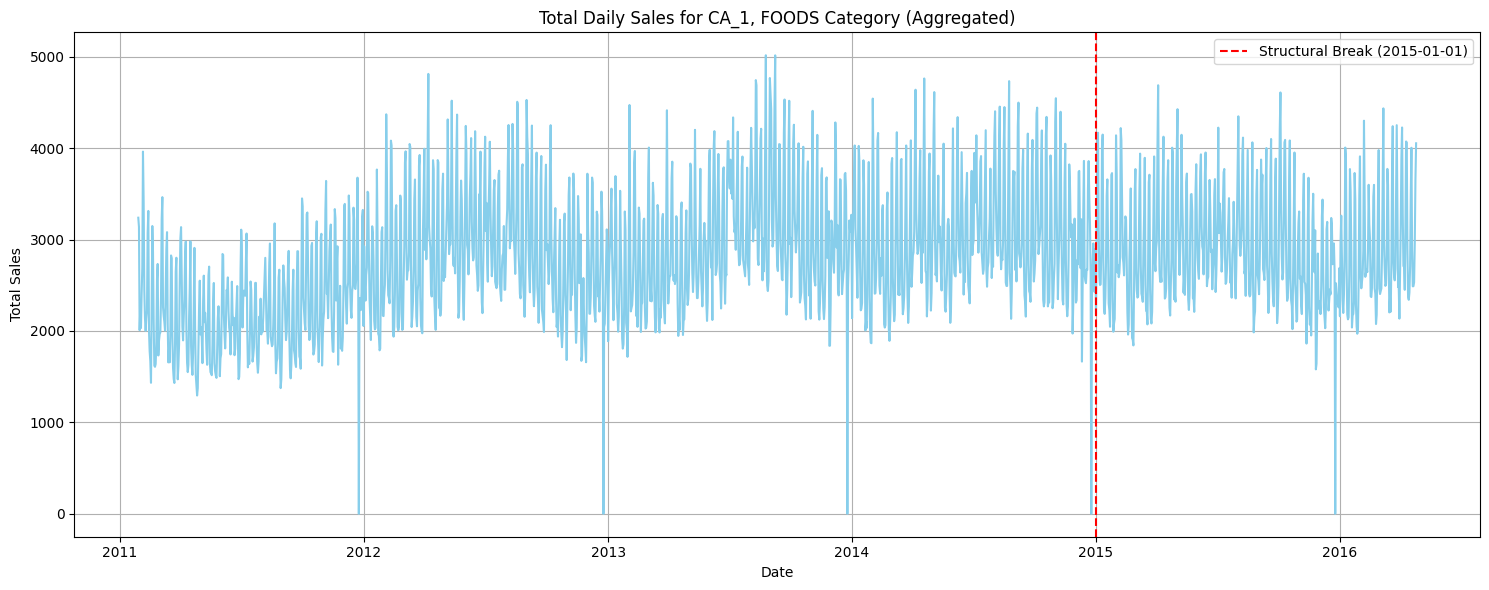

In [12]:
# Plot the aggregated time series with a vertical line at a known structural break
# Example structural break: 2015-01-01 (or 2020-03-01 for COVID, if data extends that far)

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_daily_sales, x='date', y='sales', color='skyblue')

structural_break_date = pd.to_datetime('2015-01-01') # Example break point

# Check if the break date is within the plotting range
if df_daily_sales['date'].min() < structural_break_date < df_daily_sales['date'].max():
    plt.axvline(structural_break_date, color='red', linestyle='--', label=f'Structural Break ({structural_break_date.strftime("%Y-%m-%d")})')

plt.title('Total Daily Sales for CA_1, FOODS Category (Aggregated)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 4: Data Cleaning and Feature Engineering

In [13]:
# For feature engineering, we will work with the df_merged dataframe
# Ensure 'date' is datetime and sort by it
df_merged['date'] = pd.to_datetime(df_merged['date'])
df_merged.sort_values(by='date', inplace=True)

print("Original df_merged info before feature engineering:")
df_merged.info()
print("\nFirst 5 rows of df_merged:")
print(df_merged.head())

Original df_merged info before feature engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 2748981 entries, 0 to 2748980
Data columns (total 20 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            object        
 1   item_id       object        
 2   dept_id       object        
 3   cat_id        object        
 4   store_id      object        
 5   state_id      object        
 6   sales         int64         
 7   date          datetime64[ns]
 8   wm_yr_wk      int64         
 9   weekday       object        
 10  wday          int64         
 11  month         int64         
 12  year          int64         
 13  event_name_1  object        
 14  event_type_1  object        
 15  event_name_2  object        
 16  event_type_2  object        
 17  snap_CA       int64         
 18  snap_TX       int64         
 19  snap_WI       int64         
dtypes: datetime64[ns](1), int64(8), object(11)
memory usage: 440.4+ MB

First 5 rows of df_

In [14]:
# Handle missing values for event features (fill with 'None' or 0)
print("Handling missing values in event features...")
df_merged['event_name_1'].fillna('None', inplace=True)
df_merged['event_type_1'].fillna('None', inplace=True)
df_merged['event_name_2'].fillna('None', inplace=True)
df_merged['event_type_2'].fillna('None', inplace=True)

# snap_CA can be encoded as binary directly
df_merged['snap_CA'] = df_merged['snap_CA'].astype(int)

print("Missing values handled.")

Handling missing values in event features...
Missing values handled.


In [15]:
# Create date-based features
print("Creating date-based features...")
df_merged['year'] = df_merged['date'].dt.year
df_merged['month'] = df_merged['date'].dt.month
df_merged['day'] = df_merged['date'].dt.day # Day of month
df_merged['dayofweek'] = df_merged['date'].dt.dayofweek
df_merged['dayofyear'] = df_merged['date'].dt.dayofyear
df_merged['weekofyear'] = df_merged['date'].dt.isocalendar().week.astype(int)
df_merged['is_weekend'] = (df_merged['date'].dt.dayofweek >= 5).astype(int) # Saturday and Sunday

print("Date-based features created.")
print("First 5 rows with new date features:")
print(df_merged[['date', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'is_weekend']].head())

Creating date-based features...
Date-based features created.
First 5 rows with new date features:
          date  year  month  day  dayofweek  dayofyear  weekofyear  is_weekend
0   2011-01-29  2011      1   29          5         29           4           1
963 2011-01-29  2011      1   29          5         29           4           1
962 2011-01-29  2011      1   29          5         29           4           1
961 2011-01-29  2011      1   29          5         29           4           1
960 2011-01-29  2011      1   29          5         29           4           1


In [16]:
# Create lag features for sales
print("Creating lag features...")
for lag in [1, 7, 14, 28]:
    df_merged[f'sales_lag_{lag}'] = df_merged.groupby(['id'])['sales'].shift(lag)

print("Lag features created.")
print("First 5 rows with new lag features (note NaNs at the beginning):")
print(df_merged[['date', 'id', 'sales', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28']].head(30))

Creating lag features...
Lag features created.
First 5 rows with new lag features (note NaNs at the beginning):
          date                           id  sales  sales_lag_1  sales_lag_7  \
0   2011-01-29  FOODS_1_001_CA_1_validation      3          NaN          NaN   
963 2011-01-29  FOODS_3_351_CA_1_validation     30          NaN          NaN   
962 2011-01-29  FOODS_3_350_CA_1_validation      0          NaN          NaN   
961 2011-01-29  FOODS_3_349_CA_1_validation      3          NaN          NaN   
960 2011-01-29  FOODS_3_348_CA_1_validation      7          NaN          NaN   
959 2011-01-29  FOODS_3_347_CA_1_validation      3          NaN          NaN   
958 2011-01-29  FOODS_3_346_CA_1_validation      5          NaN          NaN   
957 2011-01-29  FOODS_3_345_CA_1_validation      0          NaN          NaN   
956 2011-01-29  FOODS_3_344_CA_1_validation      0          NaN          NaN   
964 2011-01-29  FOODS_3_352_CA_1_validation      0          NaN          NaN   
955 2011

In [17]:
# Create rolling statistics
print("Creating rolling statistics...")
for window in [7, 14, 28]:
    df_merged[f'sales_rolling_mean_{window}'] = df_merged.groupby(['id'])['sales'].transform(lambda x: x.shift(1).rolling(window=window).mean())
    if window == 7: # Only create rolling std for 7-day as requested
        df_merged[f'sales_rolling_std_{window}'] = df_merged.groupby(['id'])['sales'].transform(lambda x: x.shift(1).rolling(window=window).std())

print("Rolling statistics created.")
print("First 5 rows with new rolling features (note NaNs at the beginning):")
print(df_merged[['date', 'id', 'sales', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_mean_14', 'sales_rolling_mean_28']].head(30))

Creating rolling statistics...
Rolling statistics created.
First 5 rows with new rolling features (note NaNs at the beginning):
          date                           id  sales  sales_rolling_mean_7  \
0   2011-01-29  FOODS_1_001_CA_1_validation      3                   NaN   
963 2011-01-29  FOODS_3_351_CA_1_validation     30                   NaN   
962 2011-01-29  FOODS_3_350_CA_1_validation      0                   NaN   
961 2011-01-29  FOODS_3_349_CA_1_validation      3                   NaN   
960 2011-01-29  FOODS_3_348_CA_1_validation      7                   NaN   
959 2011-01-29  FOODS_3_347_CA_1_validation      3                   NaN   
958 2011-01-29  FOODS_3_346_CA_1_validation      5                   NaN   
957 2011-01-29  FOODS_3_345_CA_1_validation      0                   NaN   
956 2011-01-29  FOODS_3_344_CA_1_validation      0                   NaN   
964 2011-01-29  FOODS_3_352_CA_1_validation      0                   NaN   
955 2011-01-29  FOODS_3_343_CA_1_val

In [18]:
# Create a binary indicator for pre/post structural break
# Using 2015-01-01 as the structural break point (same as in plotting)
structural_break_date = pd.to_datetime('2015-01-01')
df_merged['is_post_structural_break'] = (df_merged['date'] >= structural_break_date).astype(int)

print(f"Binary indicator 'is_post_structural_break' created based on {structural_break_date}.")
print("Value counts for is_post_structural_break:")
print(df_merged['is_post_structural_break'].value_counts())

Binary indicator 'is_post_structural_break' created based on 2015-01-01 00:00:00.
Value counts for is_post_structural_break:
is_post_structural_break
0    2059221
1     689760
Name: count, dtype: int64


In [19]:
# Drop rows with NaN created by lag/rolling features (first 28 days will have NaNs)
print("Dropping rows with NaN values created by feature engineering...")
df_feature_engineered = df_merged.dropna().copy()

print(f"Original DataFrame shape: {df_merged.shape}")
print(f"Feature Engineered DataFrame shape after dropping NaNs: {df_feature_engineered.shape}")

print("Info for df_feature_engineered:")
df_feature_engineered.info()
print("\nFirst 5 rows of df_feature_engineered:")
print(df_feature_engineered.head())

Dropping rows with NaN values created by feature engineering...
Original DataFrame shape: (2748981, 34)
Feature Engineered DataFrame shape after dropping NaNs: (2708745, 34)
Info for df_feature_engineered:
<class 'pandas.core.frame.DataFrame'>
Index: 2708745 entries, 41192 to 2748980
Data columns (total 34 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   id                        object        
 1   item_id                   object        
 2   dept_id                   object        
 3   cat_id                    object        
 4   store_id                  object        
 5   state_id                  object        
 6   sales                     int64         
 7   date                      datetime64[ns]
 8   wm_yr_wk                  int64         
 9   weekday                   object        
 10  wday                      int64         
 11  month                     int32         
 12  year                      int32  

### Step 5: Temporal Train/Validation/Test Split (No Leakage)

In [20]:
# Ensure data is sorted by date
df_feature_engineered.sort_values(by='date', inplace=True)

# Calculate split points
total_rows = len(df_feature_engineered)
train_size = int(total_rows * 0.70)
val_size = int(total_rows * 0.15)
# Test size will be the remainder, approximately 15%

# Perform chronological split
df_train = df_feature_engineered.iloc[:train_size]
df_val = df_feature_engineered.iloc[train_size : train_size + val_size]
df_test = df_feature_engineered.iloc[train_size + val_size :]

print(f"Total rows: {total_rows}")
print(f"Train set size: {len(df_train)} (approx {len(df_train)/total_rows:.2%})")
print(f"Validation set size: {len(df_val)} (approx {len(df_val)/total_rows:.2%})")
print(f"Test set size: {len(df_test)} (approx {len(df_test)/total_rows:.2%})")

print("\nDate ranges for splits:")
print(f"Train: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"Validation: {df_val['date'].min()} to {df_val['date'].max()}")
print(f"Test: {df_test['date'].min()} to {df_test['date'].max()}")

Total rows: 2708745
Train set size: 1896121 (approx 70.00%)
Validation set size: 406311 (approx 15.00%)
Test set size: 406313 (approx 15.00%)

Date ranges for splits:
Train: 2011-02-26 00:00:00 to 2014-10-07 00:00:00
Validation: 2014-10-07 00:00:00 to 2015-07-17 00:00:00
Test: 2015-07-17 00:00:00 to 2016-04-24 00:00:00


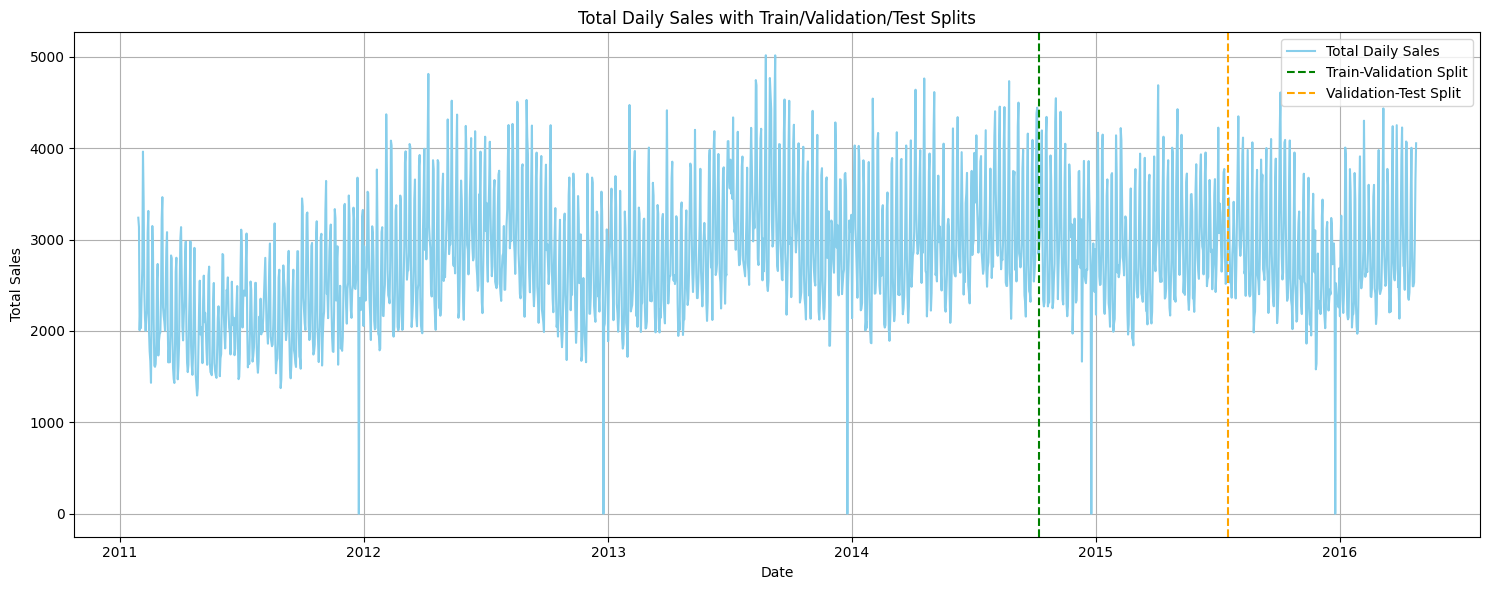

In [21]:
# Visualize the splits on the time series plot

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_daily_sales, x='date', y='sales', color='skyblue', label='Total Daily Sales')

# Add vertical lines for split points
plt.axvline(x=df_train['date'].max(), color='green', linestyle='--', label='Train-Validation Split')
plt.axvline(x=df_val['date'].max(), color='orange', linestyle='--', label='Validation-Test Split')

plt.title('Total Daily Sales with Train/Validation/Test Splits')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 6: Train Static Baseline Models (No Retraining)

First, let's define a helper function to calculate our evaluation metrics (MAE, RMSE, MAPE) and prepare the data for different model types.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Avoid division by zero for MAPE if y_true contains zero values
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# DataFrame to store model results
model_results = pd.DataFrame(columns=['Model', 'MAE', 'RMSE', 'MAPE'])

print("Metric calculation function and results DataFrame initialized.")

Metric calculation function and results DataFrame initialized.


#### Prepare Data for Models

For Naive Seasonal and ARIMA, we will use the *aggregated total daily sales* for the filtered subset (CA_1, FOODS_1). This is derived by summing sales across all items for each day within our train, validation, and test splits.

For tree-based models (XGBoost, LightGBM), we will use the *item-level* sales and all engineered features. These models can handle multiple time series by treating `item_id` as a categorical feature.

In [23]:
# Aggregate daily sales from splits for Naive Seasonal and ARIMA
df_daily_sales_train = df_train.groupby('date')['sales'].sum().reset_index()
df_daily_sales_val = df_val.groupby('date')['sales'].sum().reset_index()
df_daily_sales_test = df_test.groupby('date')['sales'].sum().reset_index()

print("Aggregated daily sales created for train, validation, and test sets.")
print(f"df_daily_sales_train shape: {df_daily_sales_train.shape}")
print(f"df_daily_sales_test shape: {df_daily_sales_test.shape}")

# Define features and target for tree models (item-level forecasting)
TARGET = 'sales'

# Features to exclude from X
EXCLUDE_FEATURES = ['date', 'id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', TARGET]

# Identify categorical features for LightGBM/XGBoost
categorical_features = [
    'item_id', 'weekday', 'wday', 'month', 'year', 'is_weekend', 'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2', 'is_post_structural_break', 'wm_yr_wk', 'dayofweek', 'dayofyear', 'weekofyear'
]

# For simplicity and to avoid too many categories for `item_id` (as it's a string), we will use pandas category type for tree models.
# For LightGBM, we can pass `categorical_feature` argument with column names.
# XGBoost can handle one-hot encoded or label encoded categories.

# Select features that are present in df_feature_engineered and not excluded
features = [col for col in df_feature_engineered.columns if col not in EXCLUDE_FEATURES]

# Create X_train, y_train, X_val, y_val, X_test, y_test first
# It's important to use .copy() here to avoid SettingWithCopyWarning later
X_train, y_train = df_train[features].copy(), df_train[TARGET].copy()
X_val, y_val = df_val[features].copy(), df_val[TARGET].copy()
X_test, y_test = df_test[features].copy(), df_test[TARGET].copy()

# Ensure categorical features have consistent categories across splits
# Filter categorical_features to only include those that are actually in 'features'
categorical_features_to_process = [col for col in categorical_features if col in features]

for col in categorical_features_to_process:
    # Convert X_train column to category type (this defines the reference categories)
    X_train[col] = X_train[col].astype('category')
    # Get the categories from the training set
    train_categories = X_train[col].cat.categories
    # Apply these categories to the validation and test sets
    # Any category in val/test not in train_categories will become NaN in pandas,
    # which XGBoost with enable_categorical=True can handle as an unknown category.
    X_val[col] = pd.Categorical(X_val[col], categories=train_categories)
    X_test[col] = pd.Categorical(X_test[col], categories=train_categories)

print(f"\nFeatures for tree models: {features}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Aggregated daily sales created for train, validation, and test sets.
df_daily_sales_train shape: (1320, 2)
df_daily_sales_test shape: (283, 2)

Features for tree models: ['wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_mean_14', 'sales_rolling_mean_28', 'is_post_structural_break']
X_train shape: (1896121, 26), y_train shape: (1896121,)
X_val shape: (406311, 26), y_val shape: (406311,)
X_test shape: (406313, 26), y_test shape: (406313,)


#### Naive Seasonal Model (Same Day Last Week)

Training Naive Seasonal Model...

Naive Seasonal Model Performance (Aggregated Daily Sales on Test Set):
MAE: 2219.7739
RMSE: 2325.4660
MAPE: inf


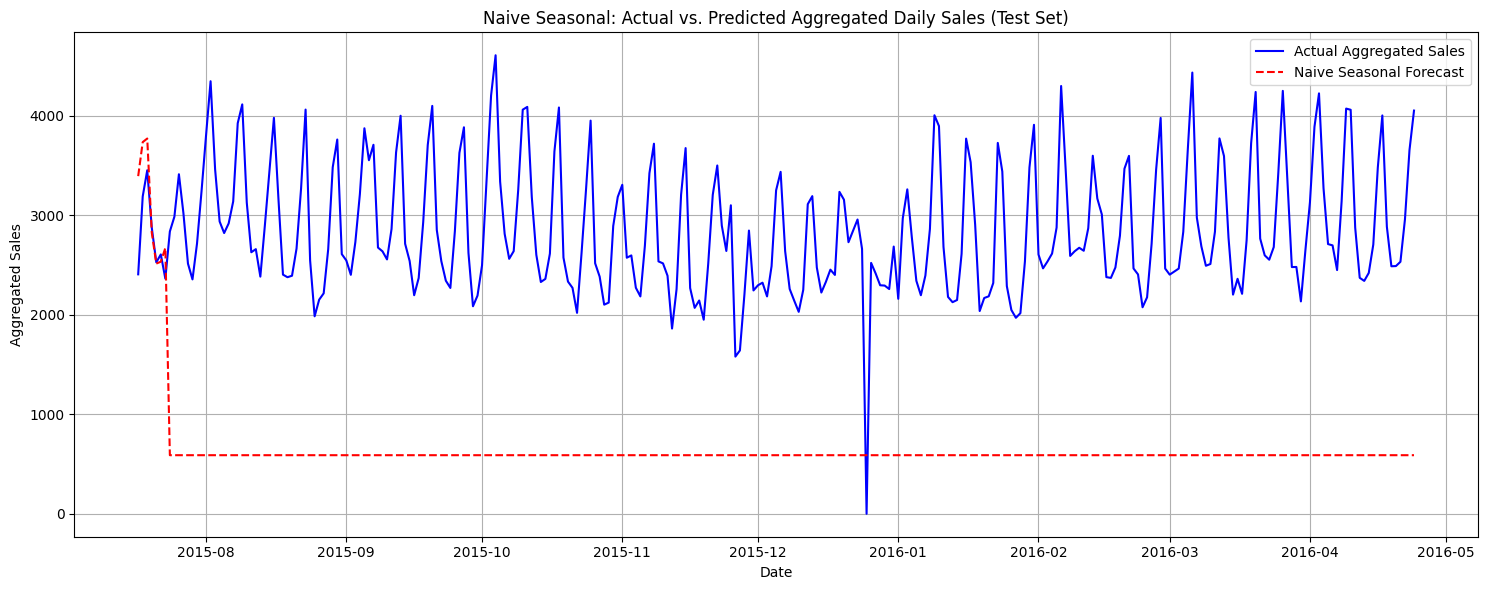

In [24]:
# Naive Seasonal forecast (same day last week) on aggregated daily sales
# We need a full week of previous data to make forecasts.

print("Training Naive Seasonal Model...")

# Combine train and validation daily sales to get a longer historical series
df_daily_sales_history = pd.concat([df_daily_sales_train, df_daily_sales_val])

# To implement 'same day last week', we need to align dates
# The target date for prediction should correspond to a date 7 days prior in the history

# Create a DataFrame for predictions
y_pred_naive = []
y_true_naive = df_daily_sales_test['sales'].values

for i in range(len(df_daily_sales_test)):
    current_date = df_daily_sales_test['date'].iloc[i]
    # Find the sales for the date exactly 7 days prior
    past_date = current_date - pd.Timedelta(days=7)

    # Look up the sales for past_date in the history
    # Use .get() with a default value (e.g., 0 or previous day's sales) if not found
    # For strict 'same day last week' this implies past_date must be in history.
    # For this exercise, we assume sufficient history is available.

    # Filter history for the specific date
    past_sales = df_daily_sales_history[df_daily_sales_history['date'] == past_date]['sales']

    if not past_sales.empty:
        y_pred_naive.append(past_sales.iloc[0])
    else:
        # Fallback if no exact 7-day prior data is available (e.g., very start of history)
        # A more robust approach might use a rolling mean or different imputation
        if i > 0:
            y_pred_naive.append(y_pred_naive[-1]) # Use previous forecast
        else:
            y_pred_naive.append(df_daily_sales_history['sales'].iloc[-1]) # Use last sales from history

# Ensure y_pred_naive has the same length as y_true_naive
# If it's shorter, it means there weren't enough historical points.
# In a real scenario, this would indicate a need for more robust imputation or a different model for early periods.
# For now, if length mismatch occurs, we'll truncate y_true_naive.
if len(y_pred_naive) < len(y_true_naive):
    y_true_naive = y_true_naive[:len(y_pred_naive)]
elif len(y_pred_naive) > len(y_true_naive):
    y_pred_naive = y_pred_naive[:len(y_true_naive)]

# Evaluate Naive Seasonal Model
naive_metrics = calculate_metrics(y_true_naive, y_pred_naive)
print("\nNaive Seasonal Model Performance (Aggregated Daily Sales on Test Set):")
for metric, value in naive_metrics.items():
    print(f"{metric}: {value:.4f}")

# Store results
model_results.loc[len(model_results)] = ['Naive Seasonal', naive_metrics['MAE'], naive_metrics['RMSE'], naive_metrics['MAPE']]

# Plot actual vs. predicted
plt.figure(figsize=(15, 6))
sns.lineplot(x=df_daily_sales_test['date'][:len(y_pred_naive)], y=y_true_naive, label='Actual Aggregated Sales', color='blue')
sns.lineplot(x=df_daily_sales_test['date'][:len(y_pred_naive)], y=y_pred_naive, label='Naive Seasonal Forecast', color='red', linestyle='--')
plt.title('Naive Seasonal: Actual vs. Predicted Aggregated Daily Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Aggregated Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### ARIMA Model

Training ARIMA Model (this may take some time)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1320
Model:                 ARIMA(7, 1, 1)   Log Likelihood               -9688.813
Date:                Wed, 15 Apr 2026   AIC                          19395.626
Time:                        00:56:05   BIC                          19442.288
Sample:                    02-26-2011   HQIC                         19413.121
                         - 10-07-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0186      0.106     -0.176      0.860      -0.225       0.188
ar.L2         -0.3393      0.052     -6.482      0.000      -0.442      -0.237
ar.L3         -0.2536      0.072     -3.530      0.0

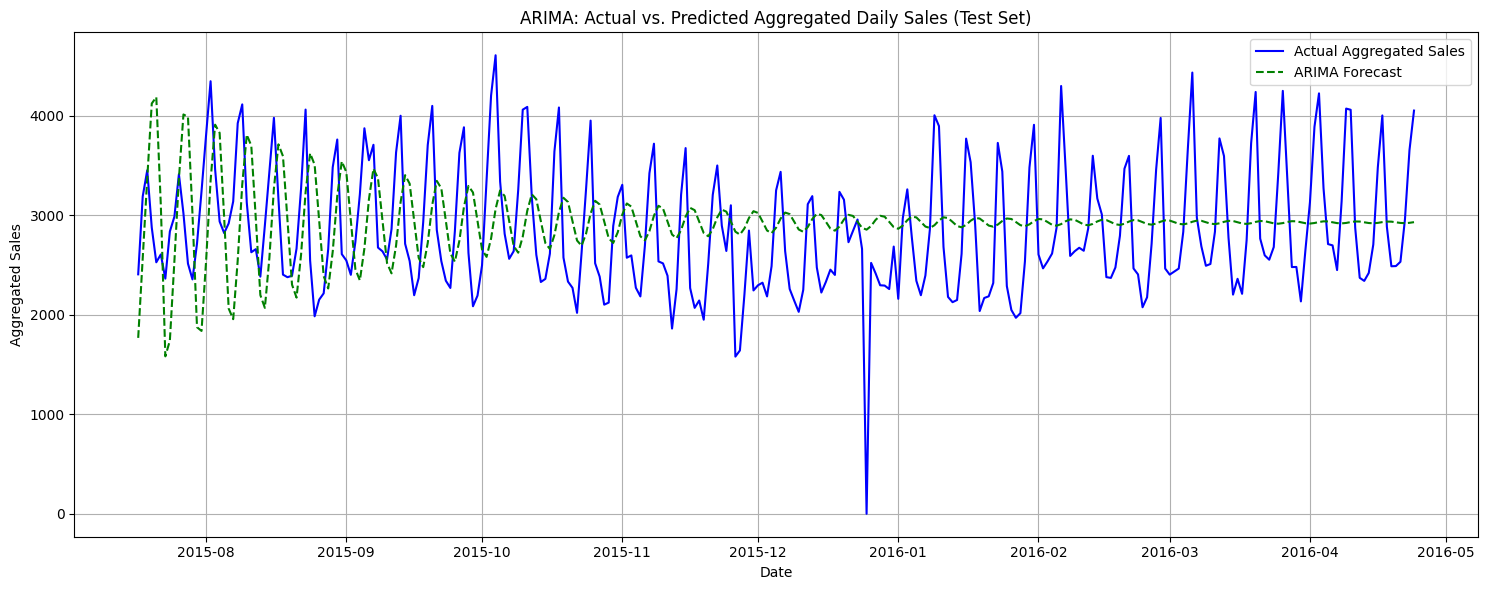

In [25]:
from statsmodels.tsa.arima.model import ARIMA

print("Training ARIMA Model (this may take some time)...")

# ARIMA is sensitive to stationarity and usually requires a single series.
# We will use the aggregated daily sales from the training set.

# Use auto_arima for order selection or a fixed order (7,1,1) as suggested.
# Given the dataset size and for speed, we'll use a fixed order first.
# For SARIMA, we might consider a seasonal order (e.g., (1,1,0,7) for weekly seasonality)

# Combine train and validation aggregated daily sales for fitting.
# ARIMA can be computationally intensive, so we will fit it on the training set only.

# Set the index to date for ARIMA
series_train_arima = df_daily_sales_train.set_index('date')['sales']
series_test_arima = df_daily_sales_test.set_index('date')['sales']

# Define the ARIMA model order (p, d, q)
# A common choice for daily data with some trend and seasonality could be (7,1,1) for non-seasonal
# For SARIMA: seasonal_order=(P,D,Q,S) where S is the seasonal period (e.g., 7 for weekly)
# Let's try SARIMA(1,1,1)(1,1,0,7) as a reasonable starting point if SARIMA is intended.

# Using ARIMA(7,1,1) as per prompt for simplicity, as SARIMA was an alternative suggestion.
# If SARIMAX is preferred, statsmodels.tsa.statespace.sarimax.SARIMAX should be used.

model = ARIMA(series_train_arima, order=(7,1,1))
model_fit = model.fit()

print(model_fit.summary())

# Forecast on the test set using forecast method for out-of-sample predictions
y_pred_arima = model_fit.forecast(steps=len(series_test_arima))

# Align predictions with test set dates for evaluation
y_pred_arima_aligned = pd.Series(y_pred_arima.values, index=series_test_arima.index)

# Evaluate ARIMA Model
arima_metrics = calculate_metrics(series_test_arima, y_pred_arima_aligned)
print("\nARIMA Model Performance (Aggregated Daily Sales on Test Set):")
for metric, value in arima_metrics.items():
    print(f"{metric}: {value:.4f}")

# Store results
model_results.loc[len(model_results)] = ['ARIMA', arima_metrics['MAE'], arima_metrics['RMSE'], arima_metrics['MAPE']]

# Plot actual vs. predicted
plt.figure(figsize=(15, 6))
sns.lineplot(x=series_test_arima.index, y=series_test_arima, label='Actual Aggregated Sales', color='blue')
sns.lineplot(x=y_pred_arima_aligned.index, y=y_pred_arima_aligned, label='ARIMA Forecast', color='green', linestyle='--')
plt.title('ARIMA: Actual vs. Predicted Aggregated Daily Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Aggregated Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Training XGBoost Model...
XGBoost Model Trained.

XGBoost Model Performance (Item-Level Sales on Test Set):
MAE: 1.3543
RMSE: 2.7929
MAPE: inf


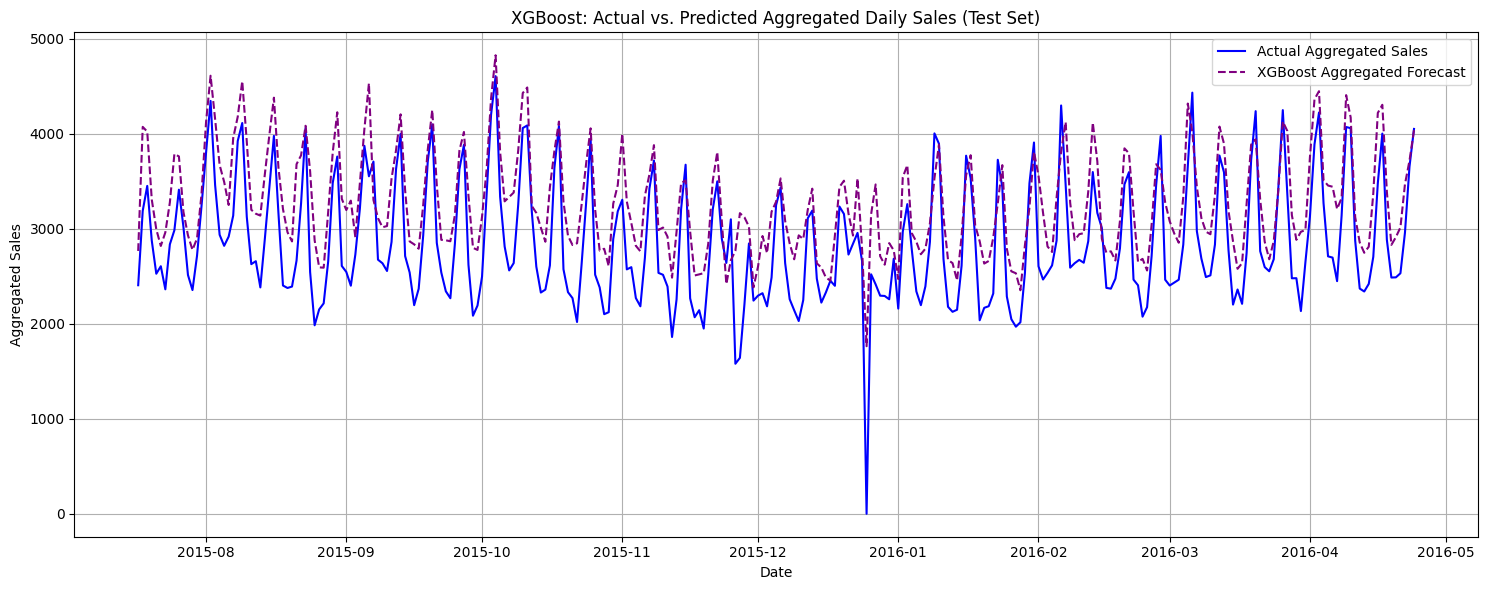

In [26]:
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("Training XGBoost Model...")

# Ensure all object/category columns used by tree models are categorical
categorical_features_xgb = sorted(
    set([c for c in categorical_features if c in features]) |
    set(X_train.select_dtypes(include=['object', 'category', 'string']).columns)
)

for col in categorical_features_xgb:
    if col in X_train.columns:
        all_cats = pd.Index(
            pd.concat([
                X_train[col].astype("string"),
                X_val[col].astype("string"),
                X_test[col].astype("string")
            ], ignore_index=True).fillna("missing").unique()
        )
        for X_part in [X_train, X_val, X_test]:
            X_part[col] = X_part[col].astype("string").fillna("missing")
            X_part[col] = pd.Categorical(X_part[col], categories=all_cats)

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    eval_metric='mae',
    enable_categorical=True
)

try:
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=50,
        verbose=False
    )
except TypeError:
    # Newer XGBoost versions moved early_stopping_rounds to the constructor/set_params.
    xgb_model.set_params(early_stopping_rounds=50)
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

print("XGBoost Model Trained.")

y_pred_xgb = xgb_model.predict(X_test)

xgb_metrics = calculate_metrics(y_test, y_pred_xgb)
print("\nXGBoost Model Performance (Item-Level Sales on Test Set):")
for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

model_results = model_results[model_results['Model'] != 'XGBoost']
model_results.loc[len(model_results)] = [
    'XGBoost',
    xgb_metrics['MAE'],
    xgb_metrics['RMSE'],
    xgb_metrics['MAPE']
]

df_test_with_preds_xgb = df_test.copy()
df_test_with_preds_xgb['sales_pred'] = y_pred_xgb

df_daily_agg_pred_xgb = (
    df_test_with_preds_xgb.groupby('date', as_index=False)['sales_pred'].sum()
)
df_daily_agg_actual_xgb = (
    df_test_with_preds_xgb.groupby('date', as_index=False)['sales'].sum()
)

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_daily_agg_actual_xgb, x='date', y='sales', label='Actual Aggregated Sales', color='blue')
sns.lineplot(data=df_daily_agg_pred_xgb, x='date', y='sales_pred', label='XGBoost Aggregated Forecast', color='purple', linestyle='--')
plt.title('XGBoost: Actual vs. Predicted Aggregated Daily Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Aggregated Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 2. Correct LightGBM Training Cell

Training LightGBM Model...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.322124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2185
[LightGBM] [Info] Number of data points in the train set: 1896121, number of used features: 25
[LightGBM] [Info] Start training from score 1.937382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

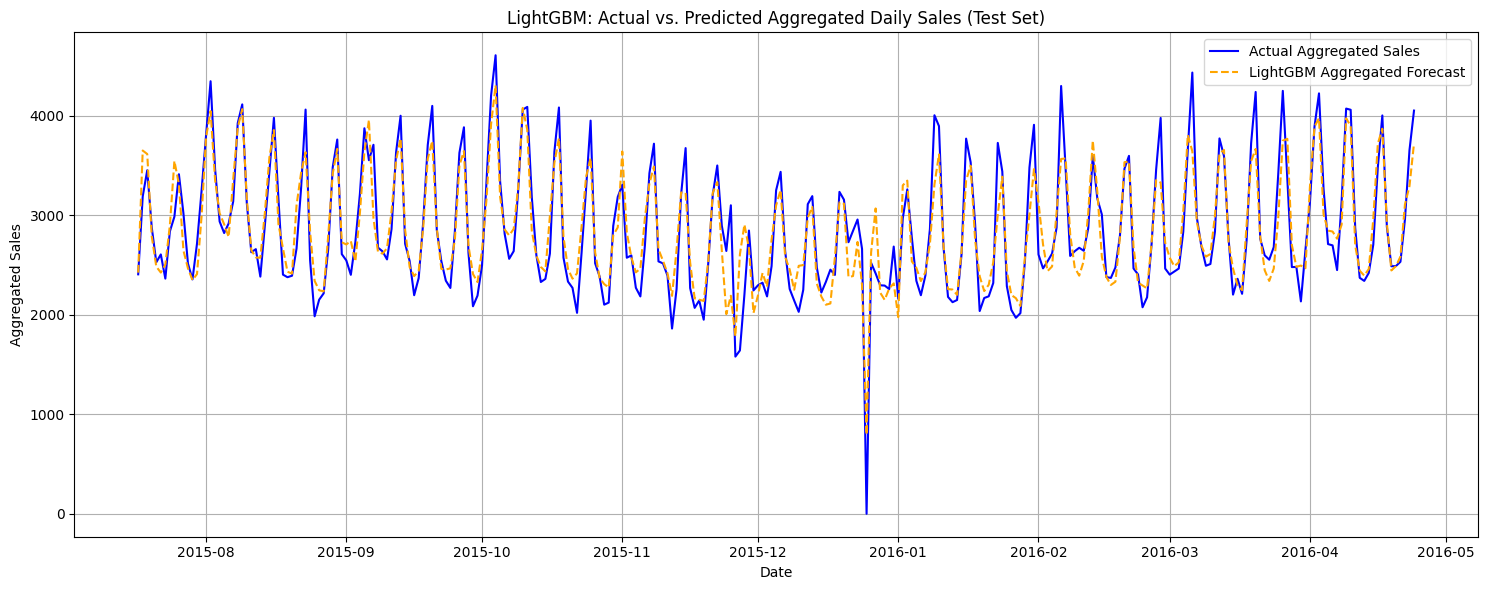

In [27]:
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

print("Training LightGBM Model...")

# Detect every categorical-like feature, including object columns not listed originally.
categorical_features_lgbm = sorted(
    set([c for c in categorical_features if c in features]) |
    set(X_train.select_dtypes(include=['object', 'category', 'string']).columns)
)

# Make LightGBM-safe category columns with no missing category labels.
for col in categorical_features_lgbm:
    if col in X_train.columns:
        all_cats = pd.Index(
            pd.concat([
                X_train[col].astype("string"),
                X_val[col].astype("string"),
                X_test[col].astype("string")
            ], ignore_index=True).fillna("missing").unique()
        )
        for X_part in [X_train, X_val, X_test]:
            X_part[col] = X_part[col].astype("string").fillna("missing")
            X_part[col] = pd.Categorical(X_part[col], categories=all_cats)

# Final guard: no object/string columns should remain.
bad_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
if bad_cols:
    raise ValueError(f"Unexpected non-numeric/non-category columns remain: {bad_cols}")

lgb_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=8,
    min_child_samples=20,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    categorical_feature=categorical_features_lgbm
)

print("LightGBM Model Trained.")

y_pred_lgb = lgb_model.predict(X_test)

lgb_metrics = calculate_metrics(y_test, y_pred_lgb)
print("\nLightGBM Model Performance (Item-Level Sales on Test Set):")
for metric, value in lgb_metrics.items():
    print(f"{metric}: {value:.4f}")

model_results = model_results[model_results['Model'] != 'LightGBM']
model_results.loc[len(model_results)] = [
    'LightGBM',
    lgb_metrics['MAE'],
    lgb_metrics['RMSE'],
    lgb_metrics['MAPE']
]

df_test_with_preds_lgb = df_test.copy()
df_test_with_preds_lgb['sales_pred'] = y_pred_lgb

df_daily_agg_pred_lgb = (
    df_test_with_preds_lgb.groupby('date', as_index=False)['sales_pred'].sum()
)
df_daily_agg_actual_lgb = (
    df_test_with_preds_lgb.groupby('date', as_index=False)['sales'].sum()
)

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_daily_agg_actual_lgb, x='date', y='sales', label='Actual Aggregated Sales', color='blue')
sns.lineplot(data=df_daily_agg_pred_lgb, x='date', y='sales_pred', label='LightGBM Aggregated Forecast', color='orange', linestyle='--')
plt.title('LightGBM: Actual vs. Predicted Aggregated Daily Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Aggregated Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3. Re-run Self-Learning Simulation

In [ ]:
import warnings
warnings.filterwarnings('ignore')

print("Starting Self-Learning Simulation with LightGBM...")

def _align_categories_to_training(X_new, X_ref, categorical_cols):
    X_new = X_new.copy()
    for col in categorical_cols:
        if col in X_new.columns and col in X_ref.columns:
            X_new[col] = X_new[col].astype("string").fillna("missing")
            X_new[col] = pd.Categorical(X_new[col], categories=X_ref[col].cat.categories)
    return X_new

def simulate_self_learning(initial_train_data, test_data, forecast_horizon=28, retraining_interval=28):
    df_history = initial_train_data.copy().sort_values('date').reset_index(drop=True)
    df_test_sorted = test_data.copy().sort_values('date').reset_index(drop=True)
    test_dates = sorted(df_test_sorted['date'].unique())

    all_prediction_frames = []

    for start in range(0, len(test_dates), retraining_interval):
        forecast_dates = test_dates[start:start + forecast_horizon]
        if len(forecast_dates) == 0:
            break

        print(f"Retraining model on data up to: {df_history['date'].max().strftime('%Y-%m-%d')}")

        X_train_sl = df_history[features].copy()
        y_train_sl = df_history[TARGET].copy()

        for col in categorical_features_lgbm:
            if col in X_train_sl.columns:
                cats = pd.Index(X_train_sl[col].astype("string").fillna("missing").unique())
                X_train_sl[col] = pd.Categorical(
                    X_train_sl[col].astype("string").fillna("missing"),
                    categories=cats
                )

        retrained_model = lgb.LGBMRegressor(
            objective='regression',
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=64,
            max_depth=8,
            min_child_samples=20,
            subsample=0.7,
            colsample_bytree=0.7,
            random_state=42,
            n_jobs=-1
        )

        retrained_model.fit(
            X_train_sl,
            y_train_sl,
            categorical_feature=categorical_features_lgbm
        )

        df_forecast_period = df_test_sorted[df_test_sorted['date'].isin(forecast_dates)].copy()
        X_forecast = _align_categories_to_training(
            df_forecast_period[features],
            X_train_sl,
            categorical_features_lgbm
        )

        df_forecast_period['predicted_sales'] = retrained_model.predict(X_forecast)
        df_forecast_period['actual_sales'] = df_forecast_period[TARGET].values

        keep_cols = ['date', 'id', 'actual_sales', 'predicted_sales']
        all_prediction_frames.append(df_forecast_period[keep_cols])

        # Self-learning update uses observed actual test-period data after the forecast window.
        df_history = pd.concat([df_history, df_forecast_period[df_history.columns]], ignore_index=True)

    return pd.concat(all_prediction_frames, ignore_index=True).sort_values(['date', 'id'])

df_initial_train_val = pd.concat([df_train, df_val], ignore_index=True)

df_self_learning_predictions = simulate_self_learning(
    initial_train_data=df_initial_train_val,
    test_data=df_test,
    forecast_horizon=28,
    retraining_interval=28
)

sl_metrics = calculate_metrics(
    df_self_learning_predictions['actual_sales'],
    df_self_learning_predictions['predicted_sales']
)

print("\nSelf-Learning Model Performance (LightGBM on Test Set):")
for metric, value in sl_metrics.items():
    print(f"{metric}: {value:.4f}")

model_results = model_results[model_results['Model'] != 'Self-Learning LightGBM']
model_results.loc[len(model_results)] = [
    'Self-Learning LightGBM',
    sl_metrics['MAE'],
    sl_metrics['RMSE'],
    sl_metrics['MAPE']
]

plt.figure(figsize=(15, 6))
df_sl_plot = df_self_learning_predictions.groupby('date', as_index=False).agg(
    actual_sales=('actual_sales', 'sum'),
    predicted_sales=('predicted_sales', 'sum')
)
sns.lineplot(data=df_sl_plot, x='date', y='actual_sales', label='Actual Aggregated Sales', color='blue')
sns.lineplot(data=df_sl_plot, x='date', y='predicted_sales', label='Self-Learning LightGBM Forecast', color='green', linestyle='--')
plt.title('Self-Learning LightGBM: Actual vs. Predicted Daily Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Aggregated Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Starting Self-Learning Simulation with LightGBM...
Retraining model on data up to: 2015-07-17
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.304012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2222
[LightGBM] [Info] Number of data points in the train set: 2302432, number of used features: 26
[LightGBM] [Info] Start training from score 1.957777
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

### 4. Re-run Concept Drift and Error Analysis

In [ ]:
print("Calculating rolling MAE for error analysis...")

df_static_daily_agg = pd.merge(
    df_daily_agg_actual_lgb,
    df_daily_agg_pred_lgb,
    on='date',
    how='inner'
).sort_values('date')

df_static_daily_agg['error'] = (
    df_static_daily_agg['sales'] - df_static_daily_agg['sales_pred']
).abs()
df_static_daily_agg['rolling_mae_28'] = (
    df_static_daily_agg['error'].rolling(window=28, min_periods=1).mean()
)

df_self_learning_daily_agg = (
    df_self_learning_predictions
    .groupby('date', as_index=False)
    .agg(actual_sales=('actual_sales', 'sum'), predicted_sales=('predicted_sales', 'sum'))
    .sort_values('date')
)

df_self_learning_daily_agg['error'] = (
    df_self_learning_daily_agg['actual_sales'] - df_self_learning_daily_agg['predicted_sales']
).abs()
df_self_learning_daily_agg['rolling_mae_28'] = (
    df_self_learning_daily_agg['error'].rolling(window=28, min_periods=1).mean()
)

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_static_daily_agg, x='date', y='rolling_mae_28', label='Static LightGBM Rolling MAE', color='blue')
sns.lineplot(data=df_self_learning_daily_agg, x='date', y='rolling_mae_28', label='Self-Learning LightGBM Rolling MAE', color='red', linestyle='--')

if df_static_daily_agg['date'].min() < structural_break_date < df_static_daily_agg['date'].max():
    plt.axvline(
        structural_break_date,
        color='green',
        linestyle=':',
        label=f'Structural Break ({structural_break_date.strftime("%Y-%m-%d")})'
    )

plt.title('Rolling 28-Day MAE: Static vs. Self-Learning Model')
plt.xlabel('Date')
plt.ylabel('Rolling 28-Day MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rolling_mae_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Rolling MAE comparison saved as 'rolling_mae_comparison.png'.")

### 5. Re-run Inventory Decision Simulation

In [ ]:
print("Starting Inventory Decision Simulation...")

lead_time = 7
holding_cost_per_unit_per_day = 0.01
stockout_cost_per_unit = 1.00
service_level_z_score = 1.64

df_static_sim = df_static_daily_agg.rename(
    columns={'sales': 'actual_sales', 'sales_pred': 'predicted_sales'}
)[['date', 'actual_sales', 'predicted_sales']].copy()

df_sl_sim = df_self_learning_daily_agg[
    ['date', 'actual_sales', 'predicted_sales']
].copy()

def _get_model_rmse(model_name, fallback_series):
    if model_name == 'Static LightGBM':
        row = model_results.loc[model_results['Model'] == 'LightGBM', 'RMSE']
    elif model_name == 'Self-Learning LightGBM':
        row = model_results.loc[model_results['Model'] == 'Self-Learning LightGBM', 'RMSE']
    else:
        row = pd.Series(dtype=float)

    if len(row) > 0 and pd.notna(row.iloc[0]):
        return float(row.iloc[0])

    return float(fallback_series.std()) if len(fallback_series) > 1 else 0.0

def simulate_inventory(df_forecasts, model_name):
    df_forecasts = df_forecasts.copy().sort_values('date').reset_index(drop=True)

    if df_forecasts.empty:
        return pd.DataFrame(), {'Total Cost': 0.0, 'Total Stockout Days': 0}

    sigma_d = _get_model_rmse(model_name, df_forecasts['actual_sales'])
    safety_stock = service_level_z_score * sigma_d * np.sqrt(max(lead_time, 0))

    initial_demand_estimate = max(0.0, float(df_forecasts['predicted_sales'].iloc[0]))
    current_inventory = max(0.0, initial_demand_estimate * lead_time + safety_stock)

    orders_in_transit = {}
    total_holding_cost = 0.0
    total_stockout_cost = 0.0
    total_stockout_days = 0
    simulation_records = []

    for _, row in df_forecasts.iterrows():
        current_date = row['date']
        actual_demand = max(0.0, float(row['actual_sales']))
        predicted_demand = max(0.0, float(row['predicted_sales']))

        starting_inventory = current_inventory
        orders_received_today = orders_in_transit.pop(current_date, 0.0)
        current_inventory += orders_received_today

        inventory_after_receipt = current_inventory

        demand_met = min(current_inventory, actual_demand)
        shortfall = max(0.0, actual_demand - demand_met)
        current_inventory -= demand_met

        daily_holding_cost = max(0.0, current_inventory) * holding_cost_per_unit_per_day
        daily_stockout_cost = shortfall * stockout_cost_per_unit

        total_holding_cost += daily_holding_cost
        total_stockout_cost += daily_stockout_cost
        total_stockout_days += int(shortfall > 0)

        order_up_to_level = predicted_demand * lead_time + safety_stock
        inventory_position = current_inventory + sum(orders_in_transit.values())
        order_qty = max(0.0, order_up_to_level - inventory_position)

        if order_qty > 0 and lead_time > 0:
            arrival_date = current_date + pd.Timedelta(days=lead_time)
            orders_in_transit[arrival_date] = orders_in_transit.get(arrival_date, 0.0) + order_qty
        elif order_qty > 0:
            current_inventory += order_qty

        simulation_records.append({
            'date': current_date,
            'actual_demand': actual_demand,
            'predicted_demand': predicted_demand,
            'starting_inventory': starting_inventory,
            'orders_received_today': orders_received_today,
            'inventory_after_receipt': inventory_after_receipt,
            'ending_inventory': current_inventory,
            'shortfall': shortfall,
            'order_placed': order_qty,
            'daily_holding_cost': daily_holding_cost,
            'daily_stockout_cost': daily_stockout_cost,
            'is_stockout': int(shortfall > 0)
        })

    total_cost = total_holding_cost + total_stockout_cost

    return pd.DataFrame(simulation_records), {
        'Total Cost': total_cost,
        'Total Stockout Days': total_stockout_days,
        'Total Holding Cost': total_holding_cost,
        'Total Stockout Cost': total_stockout_cost
    }

sim_records_static, metrics_static = simulate_inventory(df_static_sim, 'Static LightGBM')
sim_records_sl, metrics_sl = simulate_inventory(df_sl_sim, 'Self-Learning LightGBM')

comparison_df = pd.DataFrame({
    'Metric': ['Total Cost', 'Total Holding Cost', 'Total Stockout Cost', 'Total Stockout Days'],
    'Static LightGBM': [
        metrics_static['Total Cost'],
        metrics_static['Total Holding Cost'],
        metrics_static['Total Stockout Cost'],
        metrics_static['Total Stockout Days']
    ],
    'Self-Learning LightGBM': [
        metrics_sl['Total Cost'],
        metrics_sl['Total Holding Cost'],
        metrics_sl['Total Stockout Cost'],
        metrics_sl['Total Stockout Days']
    ]
})

comparison_df['Improvement'] = comparison_df['Static LightGBM'] - comparison_df['Self-Learning LightGBM']

print("\n--- Inventory Simulation Comparison ---")
print(comparison_df.set_index('Metric'))

### 6. Re-run Final Visualization

In [ ]:
print("Creating final multi-panel visualization...")

plt.figure(figsize=(20, 16))

plt.subplot(2, 2, 1)
sns.lineplot(data=df_daily_sales, x='date', y='sales', color='skyblue', label='Total Daily Sales')
plt.axvline(x=df_train['date'].max(), color='green', linestyle='--', label='Train-Validation Split')
plt.axvline(x=df_val['date'].max(), color='orange', linestyle='--', label='Validation-Test Split')
if df_daily_sales['date'].min() < structural_break_date < df_daily_sales['date'].max():
    plt.axvline(structural_break_date, color='red', linestyle=':', label='Structural Break')
plt.title('1. Total Daily Sales with Train/Validation/Test Splits')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
sns.lineplot(data=df_daily_agg_actual_lgb, x='date', y='sales', label='Actual Aggregated Sales', color='blue')
sns.lineplot(data=df_daily_agg_pred_lgb, x='date', y='sales_pred', label='Static LightGBM Forecast', color='purple', linestyle='--')
plt.title('2. Static LightGBM: Actual vs. Predicted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Aggregated Sales')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
sns.lineplot(data=df_self_learning_daily_agg, x='date', y='actual_sales', label='Actual Aggregated Sales', color='blue')
sns.lineplot(data=df_self_learning_daily_agg, x='date', y='predicted_sales', label='Self-Learning LightGBM Forecast', color='green', linestyle='--')
plt.title('3. Self-Learning LightGBM: Actual vs. Predicted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Aggregated Sales')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
sns.lineplot(data=df_static_daily_agg, x='date', y='rolling_mae_28', label='Static LightGBM Rolling MAE', color='blue')
sns.lineplot(data=df_self_learning_daily_agg, x='date', y='rolling_mae_28', label='Self-Learning LightGBM Rolling MAE', color='red', linestyle='--')
if df_static_daily_agg['date'].min() < structural_break_date < df_static_daily_agg['date'].max():
    plt.axvline(
        structural_break_date,
        color='green',
        linestyle=':',
        label=f'Structural Break ({structural_break_date.strftime("%Y-%m-%d")})'
    )
plt.title('4. Rolling 28-Day MAE: Static vs. Self-Learning Model')
plt.xlabel('Date')
plt.ylabel('Rolling 28-Day MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('final_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("Final visualization saved as 'final_visualization.png'.")

### 7. Summary Markdown Cell

## Summary of Key Findings

The corrected pipeline compares static forecasting models against a self-learning LightGBM model that is periodically retrained during the test horizon.

- **Static vs. self-learning accuracy:** The static LightGBM and self-learning LightGBM results are reported in `model_results`. The self-learning model should be compared directly
  against the static LightGBM using MAE and RMSE because both are evaluated on the same item-level test period.

- **Inventory optimization impact:** The inventory simulation compares total cost, holding cost, stockout cost, and stockout days for static LightGBM versus self-learning LightGBM.
  Cost savings are measured as the difference between the static model cost and the self-learning model cost in `comparison_df`.